# Notebook 01: Data Exploration & Chunking Strategies

## Overview

In this notebook, we will:
1. Load and explore the e-commerce FAQ dataset
2. Create custom policy documents for demonstration
3. Implement and compare 4 different chunking strategies
4. Visualize the impact of different chunking approaches
5. Understand why chunking strategy matters for RAG performance

**Learning Objectives:**
- Understand different text chunking approaches
- See the tradeoffs between chunk size, overlap, and semantic coherence
- Learn when to use each chunking strategy
- Identify the best approach for production RAG systems

---

## 1. Setup and Imports

In [1]:
# Install additional required packages
!pip install -q nltk langchain langchain-text-splitters

In [2]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict
from dotenv import load_dotenv

# Text processing
import nltk
from langchain.text_splitter import (
    RecursiveCharacterTextSplitter,
    CharacterTextSplitter
)

# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Load config
load_dotenv()

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("[OK] All libraries imported successfully")

[OK] All libraries imported successfully


---

## 2. Load E-commerce FAQ Dataset

Let's load the dataset we downloaded in Notebook 00.

In [3]:
# Load FAQ dataset
faq_df = pd.read_csv('../data/ecommerce_faq.csv')

print(f"Dataset loaded: {len(faq_df)} Q&A pairs\n")
print(f"Columns: {list(faq_df.columns)}\n")
print("First 5 rows:")
faq_df.head()

Dataset loaded: 79 Q&A pairs

Columns: ['question', 'answer']

First 5 rows:


,question,answer
0,How can I create an account?,"To create an account, click on the 'Sign Up' b..."
1,What payment methods do you accept?,"We accept major credit cards, debit cards, and..."
2,How can I track my order?,You can track your order by logging into your ...
3,What is your return policy?,Our return policy allows you to return product...
4,Can I cancel my order?,You can cancel your order if it has not been s...


### Data Statistics

In [4]:
# Calculate statistics
faq_df['question_length'] = faq_df['question'].str.len()
faq_df['answer_length'] = faq_df['answer'].str.len()
faq_df['combined_length'] = faq_df['question_length'] + faq_df['answer_length']

print("Length Statistics (characters):")
print("="*60)
print(f"Questions:")
print(f"  Mean: {faq_df['question_length'].mean():.1f}")
print(f"  Median: {faq_df['question_length'].median():.1f}")
print(f"  Min: {faq_df['question_length'].min()}")
print(f"  Max: {faq_df['question_length'].max()}")
print()
print(f"Answers:")
print(f"  Mean: {faq_df['answer_length'].mean():.1f}")
print(f"  Median: {faq_df['answer_length'].median():.1f}")
print(f"  Min: {faq_df['answer_length'].min()}")
print(f"  Max: {faq_df['answer_length'].max()}")
print()
print(f"Combined (Q+A):")
print(f"  Mean: {faq_df['combined_length'].mean():.1f}")
print(f"  Median: {faq_df['combined_length'].median():.1f}")

Length Statistics (characters):
Questions:
  Mean: 55.2
  Median: 55.0
  Min: 21
  Max: 89

Answers:
  Mean: 163.7
  Median: 162.0
  Min: 91
  Max: 219

Combined (Q+A):
  Mean: 218.9
  Median: 223.0


### Visualize Text Length Distribution

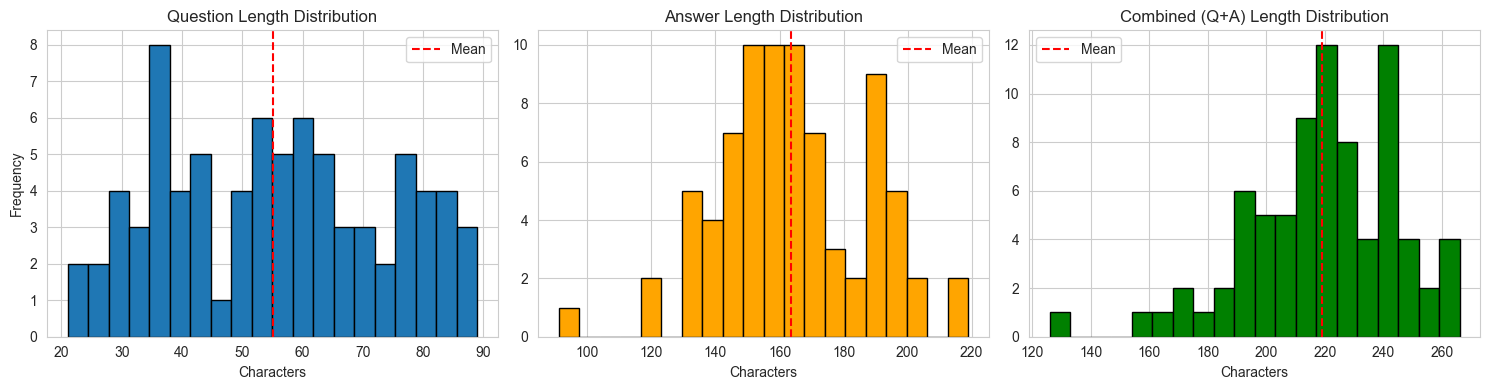


Key Observation:
Most FAQ pairs are 223 characters
This will inform our chunking strategy choices


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(faq_df['question_length'], bins=20, edgecolor='black')
axes[0].set_title('Question Length Distribution')
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Frequency')
axes[0].axvline(faq_df['question_length'].mean(), color='red', linestyle='--', label='Mean')
axes[0].legend()

axes[1].hist(faq_df['answer_length'], bins=20, edgecolor='black', color='orange')
axes[1].set_title('Answer Length Distribution')
axes[1].set_xlabel('Characters')
axes[1].axvline(faq_df['answer_length'].mean(), color='red', linestyle='--', label='Mean')
axes[1].legend()

axes[2].hist(faq_df['combined_length'], bins=20, edgecolor='black', color='green')
axes[2].set_title('Combined (Q+A) Length Distribution')
axes[2].set_xlabel('Characters')
axes[2].axvline(faq_df['combined_length'].mean(), color='red', linestyle='--', label='Mean')
axes[2].legend()

plt.tight_layout()
plt.show()

print("\nKey Observation:")
print(f"Most FAQ pairs are {faq_df['combined_length'].median():.0f} characters")
print("This will inform our chunking strategy choices")

---

## 3. Create Sample Policy Documents

Let's create longer policy documents to better demonstrate chunking strategies.

In [6]:
# Create comprehensive policy documents
return_policy = """Return Policy

Eligibility for Returns
Items can be returned within 30 days of delivery. To be eligible for a return, items must be in their original condition with all tags attached. Damaged or defective items qualify for a full refund with no restocking fee. For returns due to change of mind, a 15% restocking fee will be applied to the refund amount.

Return Process
To initiate a return, submit a return request through your account dashboard with your order number. Once approved, you will receive a return shipping label via email within 24 hours. Print the label and attach it to the package. Ship the item within 5 business days of receiving the label.

Refund Timeline
Refunds are processed within 7-10 business days after we receive and inspect the returned item. The refund will be credited to your original payment method. Please allow an additional 3-5 business days for the refund to appear in your account, depending on your bank or card issuer.

Non-returnable Items
Certain items cannot be returned for hygiene and safety reasons. These include perishable goods such as food items and flowers, personal care items including cosmetics and intimate products, and digital downloads or software once accessed. Custom or personalized items are also non-returnable unless they arrive damaged or defective.

International Returns
Customers outside the United States are responsible for return shipping costs unless the item is defective or damaged. International returns may take longer to process due to customs clearance. Refunds for international orders will be issued in USD and may be subject to currency conversion fees by your bank.
"""

shipping_policy = """Shipping Policy

Delivery Timeframes
Standard shipping typically takes 5-7 business days from the date of shipment. Express shipping is available for 2-3 business day delivery. International shipments generally arrive within 10-15 business days, though some remote locations may experience longer delivery times. All timeframes exclude weekends and holidays.

Shipping Costs
We offer free standard shipping on all orders over $50 within the continental United States. Orders under $50 incur a $5.99 standard shipping fee or $15.99 for express shipping. International shipping costs are calculated at checkout based on destination and package weight.

Order Tracking
A tracking number will be sent to your email within 24 hours of shipment. You can track your order by clicking the link in the email or by entering the tracking number on our website. For international shipments, tracking information may be limited once the package leaves the United States.

Shipping Regions
We ship to all 50 United States, including Alaska and Hawaii. International shipping is available to Canada, United Kingdom, Australia, and select European countries. Some remote or rural areas may have extended delivery times or limited carrier service.

Shipping Restrictions
Certain products cannot be shipped to international destinations due to customs regulations. Large or heavy items may require special handling and additional shipping fees. We do not ship to PO boxes for express delivery; standard shipping to PO boxes is available.
"""

warranty_policy = """Product Warranty Policy

Warranty Coverage
All products sold on our platform come with a manufacturer's warranty that covers defects in materials and workmanship. The standard warranty period is 12 months from the date of purchase. Electronics and appliances may have extended warranty options available at checkout.

What is Covered
The warranty covers manufacturing defects, faulty components, and workmanship issues that occur under normal use. This includes products that stop functioning properly, develop cracks or breaks due to material defects, or exhibit performance issues not caused by user error.

What is Not Covered
Damage caused by misuse, accidents, or improper care is not covered under warranty. Normal wear and tear, cosmetic damage that doesn't affect functionality, and damage from unauthorized repairs or modifications void the warranty. Products used for commercial purposes may have different warranty terms.

Filing a Warranty Claim
To file a warranty claim, contact our customer service team with your order number and a description of the issue. Include photos if possible. We will review your claim within 2 business days and provide instructions for returning the product if necessary. Approved warranty claims result in a free repair, replacement, or refund at our discretion.
"""

# Save to files
os.makedirs('../data/knowledge_base', exist_ok=True)

with open('../data/knowledge_base/return_policy.txt', 'w') as f:
    f.write(return_policy)

with open('../data/knowledge_base/shipping_policy.txt', 'w') as f:
    f.write(shipping_policy)

with open('../data/knowledge_base/warranty_policy.txt', 'w') as f:
    f.write(warranty_policy)

print("[OK] Policy documents created")
print(f"\nReturn Policy: {len(return_policy)} characters")
print(f"Shipping Policy: {len(shipping_policy)} characters")
print(f"Warranty Policy: {len(warranty_policy)} characters")

[OK] Policy documents created

Return Policy: 1651 characters
Shipping Policy: 1520 characters
Warranty Policy: 1307 characters


---

## 4. Chunking Strategy 1: Fixed-Size Chunking (Naive)

**Approach**: Split text into fixed-size chunks regardless of sentence boundaries.

**Pros**: Simple, fast

**Cons**: Breaks sentences mid-word, loses context

In [7]:
def fixed_size_chunking(text: str, chunk_size: int = 500) -> List[str]:
    """Split text into fixed-size chunks."""
    chunks = []
    for i in range(0, len(text), chunk_size):
        chunks.append(text[i:i+chunk_size])
    return chunks

# Test on return policy
fixed_chunks = fixed_size_chunking(return_policy, chunk_size=500)

print(f"Fixed-Size Chunking Results:")
print(f"  Total chunks: {len(fixed_chunks)}")
print(f"  Chunk sizes: {[len(c) for c in fixed_chunks]}")
print()
print("First chunk:")
print("-" * 80)
print(fixed_chunks[0])
print("-" * 80)
print()
print("Second chunk (notice how it starts mid-sentence):")
print("-" * 80)
print(fixed_chunks[1][:200] + "...")
print("-" * 80)
print()
print("PROBLEM: Chunks break in the middle of sentences, losing context!")

Fixed-Size Chunking Results:
  Total chunks: 4
  Chunk sizes: [500, 500, 500, 151]

First chunk:
--------------------------------------------------------------------------------
Return Policy

Eligibility for Returns
Items can be returned within 30 days of delivery. To be eligible for a return, items must be in their original condition with all tags attached. Damaged or defective items qualify for a full refund with no restocking fee. For returns due to change of mind, a 15% restocking fee will be applied to the refund amount.

Return Process
To initiate a return, submit a return request through your account dashboard with your order number. Once approved, you will rece
--------------------------------------------------------------------------------

Second chunk (notice how it starts mid-sentence):
--------------------------------------------------------------------------------
ive a return shipping label via email within 24 hours. Print the label and attach it to the package. Ship th

---

## 5. Chunking Strategy 2: Sentence-Based Chunking

**Approach**: Split at sentence boundaries, combine sentences until size limit.

**Pros**: Maintains sentence integrity, more readable

**Cons**: Chunk sizes vary, may miss context across sentences

In [8]:
def sentence_based_chunking(text: str, max_chunk_size: int = 500) -> List[str]:
    """Split text into chunks at sentence boundaries."""
    sentences = nltk.sent_tokenize(text)
    chunks = []
    current_chunk = ""
    
    for sentence in sentences:
        if len(current_chunk) + len(sentence) <= max_chunk_size:
            current_chunk += sentence + " "
        else:
            if current_chunk:
                chunks.append(current_chunk.strip())
            current_chunk = sentence + " "
    
    if current_chunk:
        chunks.append(current_chunk.strip())
    
    return chunks

# Test on return policy
sentence_chunks = sentence_based_chunking(return_policy, max_chunk_size=500)

print(f"Sentence-Based Chunking Results:")
print(f"  Total chunks: {len(sentence_chunks)}")
print(f"  Chunk sizes: {[len(c) for c in sentence_chunks]}")
print()
print("First chunk:")
print("-" * 80)
print(sentence_chunks[0])
print("-" * 80)
print()
print("Second chunk (notice it starts with a complete sentence):")
print("-" * 80)
print(sentence_chunks[1][:200] + "...")
print("-" * 80)
print()
print("BETTER: Chunks respect sentence boundaries, more readable!")

Sentence-Based Chunking Results:
  Total chunks: 4
  Chunk sizes: [470, 488, 495, 190]

First chunk:
--------------------------------------------------------------------------------
Return Policy

Eligibility for Returns
Items can be returned within 30 days of delivery. To be eligible for a return, items must be in their original condition with all tags attached. Damaged or defective items qualify for a full refund with no restocking fee. For returns due to change of mind, a 15% restocking fee will be applied to the refund amount. Return Process
To initiate a return, submit a return request through your account dashboard with your order number.
--------------------------------------------------------------------------------

Second chunk (notice it starts with a complete sentence):
--------------------------------------------------------------------------------
Once approved, you will receive a return shipping label via email within 24 hours. Print the label and attach it to the packag

---

## 6. Chunking Strategy 3: Recursive Character Text Splitting (Production)

**Approach**: Tries multiple separators hierarchically (paragraphs, sentences, words).

**Pros**: Best balance of quality and speed, maintains context

**Cons**: Slightly more complex

**Recommendation**: Use this for production RAG systems.

In [9]:
# Using LangChain's RecursiveCharacterTextSplitter
recursive_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50,  # Overlap to maintain context between chunks
    separators=["\n\n", "\n", ". ", " ", ""],  # Try these in order
    length_function=len
)

recursive_chunks = recursive_splitter.split_text(return_policy)

print(f"Recursive Character Splitting Results:")
print(f"  Total chunks: {len(recursive_chunks)}")
print(f"  Chunk sizes: {[len(c) for c in recursive_chunks]}")
print(f"  Overlap: 50 characters between chunks")
print()
print("First chunk:")
print("-" * 80)
print(recursive_chunks[0])
print("-" * 80)
print()
print("Second chunk:")
print("-" * 80)
print(recursive_chunks[1])
print("-" * 80)
print()
print("PRODUCTION READY: Maintains context with overlap, respects natural boundaries!")

Recursive Character Splitting Results:
  Total chunks: 5
  Chunk sizes: [354, 305, 298, 354, 331]
  Overlap: 50 characters between chunks

First chunk:
--------------------------------------------------------------------------------
Return Policy

Eligibility for Returns
Items can be returned within 30 days of delivery. To be eligible for a return, items must be in their original condition with all tags attached. Damaged or defective items qualify for a full refund with no restocking fee. For returns due to change of mind, a 15% restocking fee will be applied to the refund amount.
--------------------------------------------------------------------------------

Second chunk:
--------------------------------------------------------------------------------
Return Process
To initiate a return, submit a return request through your account dashboard with your order number. Once approved, you will receive a return shipping label via email within 24 hours. Print the label and attach it to the

---

## 7. Chunking Strategy 4: Semantic Chunking

**Approach**: Group sentences by semantic similarity.

**Pros**: Best semantic coherence

**Cons**: Requires embeddings (slower, more expensive)

**Note**: For this demo, we'll use a simple topic-based approach.

In [10]:
def semantic_chunking_simple(text: str) -> List[str]:
    """Simple semantic chunking based on section headers."""
    # Split by double newlines (section breaks)
    sections = text.split('\n\n')
    chunks = [section.strip() for section in sections if section.strip()]
    return chunks

semantic_chunks = semantic_chunking_simple(return_policy)

print(f"Semantic Chunking Results:")
print(f"  Total chunks: {len(semantic_chunks)}")
print(f"  Chunk sizes: {[len(c) for c in semantic_chunks]}")
print()
print("All chunks (grouped by topic):")
print("=" * 80)
for i, chunk in enumerate(semantic_chunks, 1):
    print(f"\nChunk {i} ({len(chunk)} chars):")
    print("-" * 80)
    print(chunk[:150] + "..." if len(chunk) > 150 else chunk)
print("\n" + "=" * 80)
print()
print("BEST FOR COHERENCE: Each chunk is a complete topic/section!")

Semantic Chunking Results:
  Total chunks: 6
  Chunk sizes: [13, 339, 305, 298, 354, 331]

All chunks (grouped by topic):

Chunk 1 (13 chars):
--------------------------------------------------------------------------------
Return Policy

Chunk 2 (339 chars):
--------------------------------------------------------------------------------
Eligibility for Returns
Items can be returned within 30 days of delivery. To be eligible for a return, items must be in their original condition with ...

Chunk 3 (305 chars):
--------------------------------------------------------------------------------
Return Process
To initiate a return, submit a return request through your account dashboard with your order number. Once approved, you will receive a ...

Chunk 4 (298 chars):
--------------------------------------------------------------------------------
Refund Timeline
Refunds are processed within 7-10 business days after we receive and inspect the returned item. The refund will be credited to yo

---

## 8. Comparison: All Strategies Side-by-Side

In [11]:
# Compare all strategies
strategies = {
    'Fixed-Size': fixed_chunks,
    'Sentence-Based': sentence_chunks,
    'Recursive': recursive_chunks,
    'Semantic': semantic_chunks
}

comparison_data = []
for name, chunks in strategies.items():
    chunk_sizes = [len(c) for c in chunks]
    comparison_data.append({
        'Strategy': name,
        'Total Chunks': len(chunks),
        'Avg Size': np.mean(chunk_sizes),
        'Min Size': np.min(chunk_sizes),
        'Max Size': np.max(chunk_sizes),
        'Std Dev': np.std(chunk_sizes)
    })

comparison_df = pd.DataFrame(comparison_data)
print("\nChunking Strategy Comparison:")
print("=" * 80)
print(comparison_df.to_string(index=False))
print("=" * 80)


Chunking Strategy Comparison:
      Strategy  Total Chunks   Avg Size  Min Size  Max Size    Std Dev
    Fixed-Size             4 412.750000       151       500 151.121433
Sentence-Based             4 410.750000       190       495 127.775927
     Recursive             5 328.400000       298       354  23.618637
      Semantic             6 273.333333        13       354 117.989642


### Visualize Chunk Size Distribution

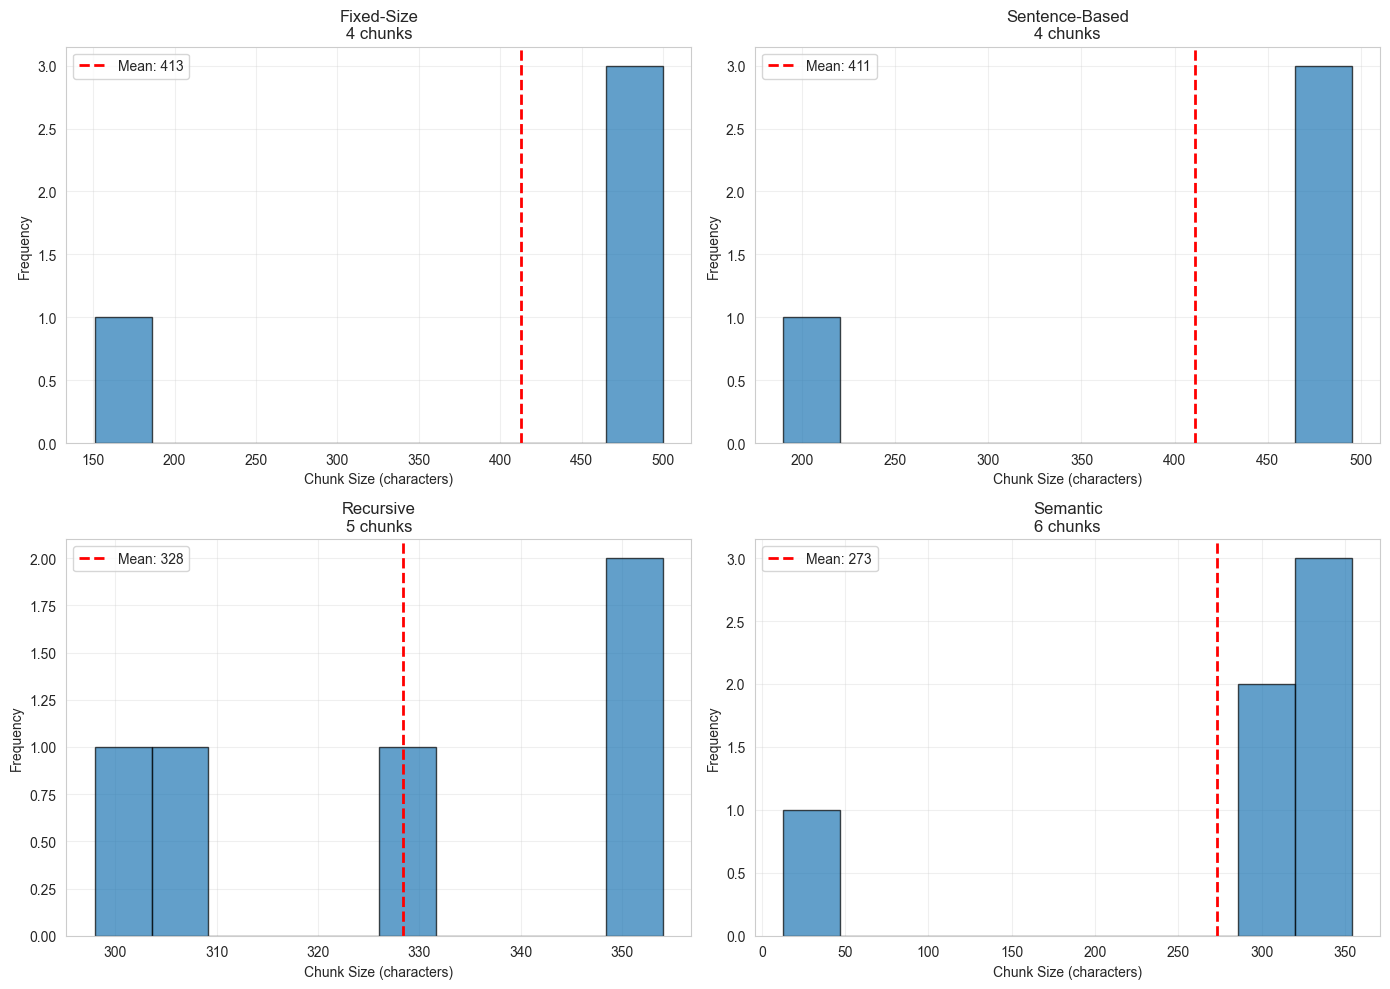


Key Observations:
- Fixed-Size: Uniform but breaks context
- Sentence-Based: Variable sizes, respects boundaries
- Recursive: Balanced approach with overlap
- Semantic: Topic-focused, most variance


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (name, chunks) in enumerate(strategies.items()):
    chunk_sizes = [len(c) for c in chunks]
    
    axes[idx].hist(chunk_sizes, bins=10, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{name}\n{len(chunks)} chunks')
    axes[idx].set_xlabel('Chunk Size (characters)')
    axes[idx].set_ylabel('Frequency')
    axes[idx].axvline(np.mean(chunk_sizes), color='red', linestyle='--', 
                     linewidth=2, label=f'Mean: {np.mean(chunk_sizes):.0f}')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey Observations:")
print("- Fixed-Size: Uniform but breaks context")
print("- Sentence-Based: Variable sizes, respects boundaries")
print("- Recursive: Balanced approach with overlap")
print("- Semantic: Topic-focused, most variance")

---

## 9. Why Chunking Matters: Impact on Retrieval

Let's demonstrate how chunking affects retrieval quality.

In [13]:
# Simulate a search query
query = "How long does it take to get a refund?"

print(f"Query: '{query}'")
print("\n" + "=" * 80)
print("\nRelevant chunks from each strategy:")
print("\n" + "=" * 80)

# For each strategy, find chunks containing "refund"
for name, chunks in strategies.items():
    print(f"\n{name}:")
    print("-" * 80)
    
    refund_chunks = [c for c in chunks if 'refund' in c.lower()]
    
    if refund_chunks:
        for i, chunk in enumerate(refund_chunks, 1):
            print(f"\nRelevant Chunk {i}:")
            # Highlight the context around "refund"
            words = chunk.split()
            for j, word in enumerate(words):
                if 'refund' in word.lower():
                    start = max(0, j-10)
                    end = min(len(words), j+15)
                    context = ' '.join(words[start:end])
                    print(f"...{context}...")
                    break
    else:
        print("No relevant chunks found")

print("\n" + "=" * 80)
print("\nConclusion:")
print("Different chunking strategies retrieve different amounts of context.")
print("Recursive and Semantic chunking provide the best balance of")
print("completeness and conciseness for answering the query.")

Query: 'How long does it take to get a refund?'


Relevant chunks from each strategy:


Fixed-Size:
--------------------------------------------------------------------------------

Relevant Chunk 1:
...tags attached. Damaged or defective items qualify for a full refund with no restocking fee. For returns due to change of mind, a 15% restocking...

Relevant Chunk 2:
...the item within 5 business days of receiving the label. Refund Timeline Refunds are processed within 7-10 business days after we receive and inspect the...

Relevant Chunk 3:
...process due to customs clearance. Refunds for international orders will be issued in USD and may be subject to currency...

Sentence-Based:
--------------------------------------------------------------------------------

Relevant Chunk 1:
...tags attached. Damaged or defective items qualify for a full refund with no restocking fee. For returns due to change of mind, a 15% restocking...

Relevant Chunk 2:
...the item within 5 business days of rec

---

## 10. Recommendations: Choosing the Right Strategy

### Decision Matrix

| Use Case | Recommended Strategy | Why |
|----------|---------------------|-----|
| **Production RAG** | Recursive Character Splitting | Best balance of quality, speed, and context preservation |
| **FAQ/Q&A pairs** | Keep intact (no chunking) | Each pair is already a semantic unit |
| **Long documents** | Semantic chunking | Maintains topic coherence |
| **Code documentation** | Recursive with code-aware separators | Respects code structure |
| **Chat transcripts** | Speaker-turn based | Maintains conversation flow |

### Key Parameters to Tune

1. **Chunk Size**
   - Too small (< 200 chars): Loses context
   - Too large (> 1000 chars): Reduces retrieval precision
   - Recommended: 400-600 characters

2. **Chunk Overlap**
   - 0%: Risk losing context at boundaries
   - 10-20%: Good balance (50-100 chars for 500 char chunks)
   - > 30%: Redundant, increases storage

3. **Separators**
   - Try paragraph breaks first (\n\n)
   - Then sentences (. )
   - Finally words ( )
   - Use domain-specific separators when applicable

---

## 11. Prepare Data for Next Notebook

Let's save our chunked data for use in the RAG pipeline.

In [14]:
# Use Recursive Character Splitting for production
print("Preparing knowledge base with Recursive Character Splitting...")
print()

all_chunks = []

# Process policy documents
policies = {
    'return_policy': return_policy,
    'shipping_policy': shipping_policy,
    'warranty_policy': warranty_policy
}

for policy_name, policy_text in policies.items():
    chunks = recursive_splitter.split_text(policy_text)
    for i, chunk in enumerate(chunks):
        all_chunks.append({
            'chunk_id': f"{policy_name}_{i}",
            'source': policy_name,
            'text': chunk,
            'chunk_index': i,
            'total_chunks': len(chunks)
        })

# Add FAQ pairs (no chunking needed - already atomic)
for idx, row in faq_df.iterrows():
    all_chunks.append({
        'chunk_id': f"faq_{idx}",
        'source': 'faq',
        'text': f"Q: {row['question']}\nA: {row['answer']}",
        'chunk_index': idx,
        'total_chunks': len(faq_df)
    })

# Save to JSON
chunks_df = pd.DataFrame(all_chunks)
chunks_df.to_json('../data/knowledge_base_chunks.json', orient='records', indent=2)

print(f"[OK] Knowledge base prepared")
print(f"  Total chunks: {len(all_chunks)}")
print(f"  Policy chunks: {sum(1 for c in all_chunks if c['source'] != 'faq')}")
print(f"  FAQ chunks: {sum(1 for c in all_chunks if c['source'] == 'faq')}")
print(f"\nSaved to: ../data/knowledge_base_chunks.json")

Preparing knowledge base with Recursive Character Splitting...

[OK] Knowledge base prepared
  Total chunks: 93
  Policy chunks: 14
  FAQ chunks: 79

Saved to: ../data/knowledge_base_chunks.json


---

## Summary

In this notebook, we:

1. Explored the e-commerce FAQ dataset
2. Created comprehensive policy documents
3. Implemented 4 different chunking strategies:
   - Fixed-Size (naive)
   - Sentence-Based (better)
   - Recursive Character Splitting (production)
   - Semantic (best coherence)
4. Compared strategies with visualizations
5. Demonstrated impact on retrieval quality
6. Prepared chunked knowledge base for RAG pipeline

**Key Takeaway**: 
Chunking strategy significantly impacts RAG performance. For production systems, use **Recursive Character Text Splitting** with:
- Chunk size: 400-600 characters
- Overlap: 10-20%
- Hierarchical separators

**Next**: In Notebook 02, we'll build the baseline RAG system using these chunks!